# Algebraic compatibility governs trainability in variational quantum models

**Jesús-Ángel Román-Gallego & Roberto Casado**  
Universidad de Salamanca — Departamento de Informática y Automática

---

This notebook contains the **numerical experiments** from Section 6 of the paper:

> *Algebraic compatibility governs trainability in variational quantum models*
---

## Overview

We empirically validate the **compatibility index** framework introduced in the paper.  
The key claim: gradient signal in a variational quantum model is governed not merely by expressibility,
but by the **algebraic compatibility** between the dynamic Lie algebra of the ansatz and the
commutator structure of the learning task.

The effective compatibility proxy is:

$$
c_{\mathrm{eff}} \approx \frac{1}{p} \frac{\sum_{j=1}^{p} |\mathrm{Tr}(\rho [G_j, O])|^2}{\|O\|^2 \,\mathrm{Tr}(\rho^2)}
$$

where $\{G_j\}$ are the generators of the ansatz.

---

## Structure

| Section | Content |
|---|---|
| **Setup** | Install/import libraries, define utilities |
| **Section 6.1** | Ansatz definitions (HEA and restricted) |
| **Section 6.2** | Compatibility vs. gradient signal (4 qubits) |
| **Section 6.3** | System-size scaling and signal dilution |
| **Section 6.4** | Algebra–observable alignment experiment |

---

### Requirements
```
qiskit >= 2.0
numpy
matplotlib
pandas
pylatexenc   # for circuit diagrams
```

In [1]:
# ─────────────────────────────────────────────────────────────────────────────
# Install dependencies (only needed in fresh environments, e.g. Google Colab)
# ─────────────────────────────────────────────────────────────────────────────
!pip install qiskit pylatexenc --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 5.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 58.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 44.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 2.6 MB/s eta 0:00:00


---
## 1. Imports and utilities

We use **Qiskit** for circuit simulation and **NumPy** for linear algebra.
All expectation values are computed via exact statevector simulation.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import List, Dict, Tuple

from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector, Parameter
from qiskit.quantum_info import Statevector, SparsePauliOp, Operator

### 1.1 State and observable helpers

In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# Initial-state constructors
# ─────────────────────────────────────────────────────────────────────────────

def zero_state(num_qubits: int) -> Statevector:
    """Return |0...0> as a Statevector."""
    return Statevector.from_label("0" * num_qubits)


def plus_zero_state(num_qubits: int, plus_qubit: int = 0) -> Statevector:
    """
    Return |+> on `plus_qubit` and |0> on all others.
    Used for Benchmark B: coherence on qubit 0.
    """
    qc = QuantumCircuit(num_qubits)
    qc.h(plus_qubit)
    return Statevector.from_instruction(qc)


# ─────────────────────────────────────────────────────────────────────────────
# Observable constructors
# Qiskit uses little-endian ordering: the rightmost character acts on qubit 0.
# ─────────────────────────────────────────────────────────────────────────────

def observable_local_x(num_qubits: int, target: int = 0) -> SparsePauliOp:
    """Return X acting on `target` qubit, identity elsewhere."""
    label = ["I"] * num_qubits
    label[num_qubits - 1 - target] = "X"
    return SparsePauliOp(["".join(label)], coeffs=[1.0])


def observable_local_z(num_qubits: int, target: int = 0) -> SparsePauliOp:
    """Return Z acting on `target` qubit, identity elsewhere."""
    label = ["I"] * num_qubits
    label[num_qubits - 1 - target] = "Z"
    return SparsePauliOp(["".join(label)], coeffs=[1.0])

### 1.2 Hilbert–Schmidt utilities

In [4]:
def hs_norm_squared(op: SparsePauliOp) -> float:
    """Hilbert-Schmidt norm squared: ||O||² = Tr(O†O)."""
    mat = Operator(op).data
    return float(np.real(np.trace(mat.conj().T @ mat)))


def purity_statevector(state: Statevector) -> float:
    """Purity of a pure state: Tr(ρ²) = 1."""
    return 1.0


def density_matrix(state: Statevector) -> np.ndarray:
    """Return ρ = |ψ⟩⟨ψ| as a NumPy matrix."""
    vec = state.data.reshape(-1, 1)
    return vec @ vec.conj().T

### 1.3 Gradient computation via parameter-shift rule

For gates of the form $e^{-i\theta G/2}$ (standard RY/RZ),  
the parameter-shift rule gives:

$$
\frac{\partial \mathcal{L}}{\partial \theta_j}
= \frac{1}{2}\bigl[\mathcal{L}(\theta_j + \tfrac{\pi}{2}) - \mathcal{L}(\theta_j - \tfrac{\pi}{2})\bigr]
$$

In [5]:
def expectation_value(
    circuit: QuantumCircuit,
    parameter_values: np.ndarray,
    observable: SparsePauliOp,
    initial_state: Statevector,
) -> float:
    """Evaluate ⟨O⟩ for the bound circuit via exact statevector simulation."""
    bound = circuit.assign_parameters(
        {p: v for p, v in zip(circuit.parameters, parameter_values)},
        inplace=False
    )
    final_state = initial_state.evolve(bound)
    return float(np.real(final_state.expectation_value(observable)))


def parameter_shift_gradient(
    circuit: QuantumCircuit,
    parameter_values: np.ndarray,
    observable: SparsePauliOp,
    initial_state: Statevector,
    shift: float = np.pi / 2,
) -> np.ndarray:
    """
    Parameter-shift gradient for circuits with RX/RY/RZ gates.
    Uses the standard two-point shift rule.
    """
    grads = np.zeros(len(parameter_values), dtype=float)
    for j in range(len(parameter_values)):
        plus = parameter_values.copy()
        minus = parameter_values.copy()
        plus[j] += shift
        minus[j] -= shift
        f_plus  = expectation_value(circuit, plus,  observable, initial_state)
        f_minus = expectation_value(circuit, minus, observable, initial_state)
        grads[j] = 0.5 * (f_plus - f_minus)
    return grads

---
## 2. Ansatz definitions (Section 6.1)

We compare two families of parametrized circuits:

1. **Hardware-Efficient Ansatz (HEA):** RY–RZ layers on *all* qubits + CX chain entangling structure.  
   Generates a large dynamic Lie algebra spreading across the full Hilbert space.

2. **Restricted Local Ansatz:** Same RY–RZ structure, but confined to an *active subset* of qubits.  
   Generates a smaller, more task-aligned algebra.

These two ansätze are the central contrast in the experiments.

In [6]:
@dataclass
class AnsatzSpec:
    """Container for a parametrized circuit and its metadata."""
    circuit: QuantumCircuit
    parameters: List[Parameter]
    generator_labels: List[Tuple[str, int]]  # e.g. [('Y', 0), ('Z', 0), ...]
    name: str


def hardware_efficient_ansatz(num_qubits: int, reps: int = 2) -> AnsatzSpec:
    """
    Hardware-Efficient Ansatz (HEA).

    Structure: `reps` layers of RY(θ)–RZ(θ) on all qubits,
    followed by a nearest-neighbour CX chain.

    Total parameters: 2 * num_qubits * reps.
    DLA: large, spreads over the full system.
    """
    qc = QuantumCircuit(num_qubits)
    thetas = ParameterVector("θ", length=2 * num_qubits * reps)
    generator_labels = []
    idx = 0

    for _ in range(reps):
        for q in range(num_qubits):
            qc.ry(thetas[idx], q);  generator_labels.append(("Y", q));  idx += 1
            qc.rz(thetas[idx], q);  generator_labels.append(("Z", q));  idx += 1
        for q in range(num_qubits - 1):
            qc.cx(q, q + 1)

    return AnsatzSpec(
        circuit=qc,
        parameters=list(thetas),
        generator_labels=generator_labels,
        name=f"HEA_{num_qubits}q_{reps}rep"
    )


def restricted_local_ansatz(
    num_qubits: int,
    active_qubits: List[int],
    reps: int = 2
) -> AnsatzSpec:
    """
    Restricted Local Ansatz.

    Same RY–RZ structure but only acting on `active_qubits`.
    CX gates are also local (within the active subset).

    Total parameters: 2 * len(active_qubits) * reps.
    DLA: smaller, concentrated on the relevant subsystem.
    """
    qc = QuantumCircuit(num_qubits)
    thetas = ParameterVector("φ", length=2 * len(active_qubits) * reps)
    generator_labels = []
    idx = 0

    for _ in range(reps):
        for q in active_qubits:
            qc.ry(thetas[idx], q);  generator_labels.append(("Y", q));  idx += 1
            qc.rz(thetas[idx], q);  generator_labels.append(("Z", q));  idx += 1
        for a, b in zip(active_qubits[:-1], active_qubits[1:]):
            qc.cx(a, b)

    return AnsatzSpec(
        circuit=qc,
        parameters=list(thetas),
        generator_labels=generator_labels,
        name=f"Restricted_{num_qubits}q_{reps}rep_active_{active_qubits}"
    )

---
## 3. Effective Compatibility Proxy (Definition 1 in the paper)

The **compatibility index** is defined as:

$$
C(\mathfrak{g}, \rho, O) = \frac{1}{\dim(\mathfrak{g})} \cdot
\frac{\sum_{X \in B(\mathfrak{g})} |\mathrm{Tr}(\rho [X, O])|^2}{\|O\|^2 \,\mathrm{Tr}(\rho^2)}
$$

We estimate this using the ansatz **generators** $\{G_j\}$ as an orthonormal basis proxy:

$$
c_{\mathrm{eff}} \approx \frac{1}{p} \frac{\sum_{j=1}^{p} |\mathrm{Tr}(\rho [G_j, O])|^2}{\|O\|^2 \,\mathrm{Tr}(\rho^2)}
$$

This is a practical estimator restricted to the directions accessible by the circuit.

In [7]:
def single_qubit_pauli_generator(
    num_qubits: int, pauli: str, target: int
) -> np.ndarray:
    """
    Return the embedded single-qubit Pauli operator acting on `target`,
    with identity on all other qubits.
    Follows Qiskit's little-endian qubit ordering.
    """
    label = ["I"] * num_qubits
    label[num_qubits - 1 - target] = pauli
    op = SparsePauliOp(["".join(label)], coeffs=[1.0])
    return Operator(op).data


def effective_compatibility_proxy(
    num_qubits: int,
    initial_state: Statevector,
    observable: SparsePauliOp,
    generator_labels: List[Tuple[str, int]],
) -> float:
    """
    Compute the effective compatibility proxy c_eff.

    This is NOT the exact DLA-based C(g, ρ, O), but a practical
    estimator using the ansatz generators as the algebra basis.

    Parameters
    ----------
    num_qubits      : total system size
    initial_state   : input state ρ = |ψ⟩⟨ψ|
    observable      : Hermitian observable O
    generator_labels: list of (Pauli_char, qubit_index) for each gate

    Returns
    -------
    c_eff : float
    """
    rho = density_matrix(initial_state)
    O   = Operator(observable).data

    numer_terms = []
    for pauli, q in generator_labels:
        G   = single_qubit_pauli_generator(num_qubits, pauli, q)
        comm = G @ O - O @ G         # commutator [G, O]
        val  = np.trace(rho @ comm)  # Tr(ρ [G, O])
        numer_terms.append(np.abs(val) ** 2)

    numer = float(np.sum(numer_terms))
    denom = hs_norm_squared(observable) * purity_statevector(initial_state)
    p     = len(generator_labels)

    return numer / (p * denom)

---
## 4. Experiment runner

For each (ansatz, observable, initial state) combination:
- Sample `n_samples` random parameter configurations from $[-\pi, \pi]^p$
- Compute cost values and gradients (parameter-shift rule)
- Estimate gradient variance across both parameters and samples
- Compute the effective compatibility proxy $c_{\mathrm{eff}}$

In [8]:
def run_benchmark(
    ansatz_spec: AnsatzSpec,
    observable: SparsePauliOp,
    initial_state: Statevector,
    n_samples: int = 100,
    seed: int = 1234,
) -> Dict[str, np.ndarray]:
    """
    Run a single (ansatz, observable, state) benchmark.

    Returns a dict with keys:
      - 'costs'             : shape (n_samples,)
      - 'gradients'         : shape (n_samples, num_params)
      - 'grad_var_per_param': shape (num_params,)  -- variance per parameter
      - 'grad_var_mean'     : shape (1,)           -- mean over parameters
      - 'c_eff'             : shape (1,)           -- compatibility proxy
    """
    rng = np.random.default_rng(seed)
    p   = len(ansatz_spec.parameters)
    costs, gradients = [], []

    for _ in range(n_samples):
        theta = rng.uniform(-np.pi, np.pi, size=p)
        costs.append(
            expectation_value(ansatz_spec.circuit, theta, observable, initial_state)
        )
        gradients.append(
            parameter_shift_gradient(ansatz_spec.circuit, theta, observable, initial_state)
        )

    costs     = np.array(costs)
    gradients = np.array(gradients)

    grad_var_per_param = np.var(gradients, axis=0)
    grad_var_mean      = float(np.mean(grad_var_per_param))

    c_eff = effective_compatibility_proxy(
        num_qubits=ansatz_spec.circuit.num_qubits,
        initial_state=initial_state,
        observable=observable,
        generator_labels=ansatz_spec.generator_labels,
    )

    return {
        "costs":              costs,
        "gradients":          gradients,
        "grad_var_per_param": grad_var_per_param,
        "grad_var_mean":      np.array([grad_var_mean]),
        "c_eff":              np.array([c_eff]),
    }

---
## 5. Circuit visualization utilities

In [9]:
def print_circuit_info(ansatz_spec: AnsatzSpec) -> None:
    """Print metadata and ASCII diagram of a circuit."""
    print("\n" + "=" * 70)
    print(f"Circuit name: {ansatz_spec.name}")
    print(f"Number of qubits: {ansatz_spec.circuit.num_qubits}")
    print(f"Number of parameters: {len(ansatz_spec.parameters)}")
    print("Parameters:", [str(p) for p in ansatz_spec.parameters])
    print("Generator labels:", ansatz_spec.generator_labels)
    print("-" * 70)
    print(ansatz_spec.circuit.draw(output="text"))
    print("=" * 70 + "\n")


def save_circuit_mpl(
    ansatz_spec: AnsatzSpec,
    filename: str,
    scale: float = 0.8,
    idle_wires: bool = False
) -> None:
    """Save a Matplotlib circuit diagram to `filename` (PDF recommended)."""
    fig = ansatz_spec.circuit.draw(
        output="mpl", fold=-1, scale=scale,
        idle_wires=idle_wires, style="bw"
    )
    fig.savefig(filename, bbox_inches="tight", transparent=True)
    plt.close(fig)
    print(f"Circuit saved to: {filename}")

---
## 6. Section 6.1 – Experimental Setup

We fix **n = 4 qubits** and **2 repetitions** (L = 2 layers) for both ansätze.

- **Benchmark A:** $O = X_1$, $\rho = |0\rangle^{\otimes n}$  
  → probes coherence-generating directions ($[X_1, \rho] \neq 0$)

- **Benchmark B:** $O = Z_1$, $\rho = |+\rangle \otimes |0\rangle^{\otimes (n-1)}$  
  → non-trivial compatibility from the coherence on qubit 0

In [10]:
# ─── Experiment hyperparameters ───────────────────────────────────────────────
NUM_QUBITS = 4
REPS       = 2
N_SAMPLES  = 200
SEED       = 7

# ─── Initial states ───────────────────────────────────────────────────────────
psi0       = zero_state(NUM_QUBITS)                  # |0...0>
psi_plus0  = plus_zero_state(NUM_QUBITS, plus_qubit=0)  # |+0...0>

# ─── Observables (both acting on qubit 0) ─────────────────────────────────────
obs_x1 = observable_local_x(NUM_QUBITS, target=0)   # X₁
obs_z1 = observable_local_z(NUM_QUBITS, target=0)   # Z₁

# ─── Ansätze ──────────────────────────────────────────────────────────────────
hea        = hardware_efficient_ansatz(num_qubits=NUM_QUBITS, reps=REPS)
restricted = restricted_local_ansatz(num_qubits=NUM_QUBITS, active_qubits=[0, 1], reps=REPS)

# ─── Display circuits ─────────────────────────────────────────────────────────
print_circuit_info(hea)
print_circuit_info(restricted)

# (Optional) Export circuit diagrams as PDF
# save_circuit_mpl(hea,        "fig_HEA_circuit.pdf",        scale=0.7, idle_wires=False)
# save_circuit_mpl(restricted, "fig_restricted_circuit.pdf", scale=0.9, idle_wires=True)


Circuit name: HEA_4q_2rep
Number of qubits: 4
Number of parameters: 16
Parameters: ['θ[0]', 'θ[1]', 'θ[2]', 'θ[3]', 'θ[4]', 'θ[5]', 'θ[6]', 'θ[7]', 'θ[8]', 'θ[9]', 'θ[10]', 'θ[11]', 'θ[12]', 'θ[13]', 'θ[14]', 'θ[15]']
Generator labels: [('Y', 0), ('Z', 0), ('Y', 1), ('Z', 1), ('Y', 2), ('Z', 2), ('Y', 3), ('Z', 3), ('Y', 0), ('Z', 0), ('Y', 1), ('Z', 1), ('Y', 2), ('Z', 2), ('Y', 3), ('Z', 3)]
----------------------------------------------------------------------
     ┌──────────┐┌──────────┐     ┌──────────┐ ┌──────────┐             »
q_0: ┤ Ry(θ[0]) ├┤ Rz(θ[1]) ├──■──┤ Ry(θ[8]) ├─┤ Rz(θ[9]) ├─────────────»
     ├──────────┤├──────────┤┌─┴─┐└──────────┘┌┴──────────┤┌───────────┐»
q_1: ┤ Ry(θ[2]) ├┤ Rz(θ[3]) ├┤ X ├─────■──────┤ Ry(θ[10]) ├┤ Rz(θ[11]) ├»
     ├──────────┤├──────────┤└───┘   ┌─┴─┐    └───────────┘├───────────┤»
q_2: ┤ Ry(θ[4]) ├┤ Rz(θ[5]) ├────────┤ X ├──────────■──────┤ Ry(θ[12]) ├»
     ├──────────┤├──────────┤        └───┘        ┌─┴─┐    ├───────────┤»
q_3: ┤ Ry(θ[6

---
## 7. Section 6.2 – Compatibility vs. Gradient Signal

We compare $c_{\mathrm{eff}}$ and mean gradient variance for HEA vs. restricted ansatz  
on both benchmarks with $n = 4$ qubits.

**Expected:** The restricted ansatz (which concentrates its generators on the  
subsystem directly involved in the learning task) achieves higher $c_{\mathrm{eff}}$  
and a stronger gradient signal — in line with Corollary 4.2 of the paper.

In [11]:
# ─── Benchmark A: X₁ with |0...0> ────────────────────────────────────────────
print("#" * 70)
print("Benchmark A: observable X1 with initial state |0...0>")
print("#" * 70)

out_hea_x1 = run_benchmark(hea,        obs_x1, psi0,      n_samples=N_SAMPLES, seed=SEED)
out_res_x1 = run_benchmark(restricted, obs_x1, psi0,      n_samples=N_SAMPLES, seed=SEED)

print(f"[HEA,        X1, |0...0>]  c_eff = {out_hea_x1['c_eff'][0]:.6f},"
      f"  mean grad var = {out_hea_x1['grad_var_mean'][0]:.6e}")
print(f"[Restricted, X1, |0...0>]  c_eff = {out_res_x1['c_eff'][0]:.6f},"
      f"  mean grad var = {out_res_x1['grad_var_mean'][0]:.6e}")

# ─── Benchmark B: Z₁ with |+0...0> ───────────────────────────────────────────
print("\n" + "#" * 70)
print("Benchmark B: observable Z1 with initial state |+0...0>")
print("#" * 70)

out_hea_z1 = run_benchmark(hea,        obs_z1, psi_plus0, n_samples=N_SAMPLES, seed=SEED)
out_res_z1 = run_benchmark(restricted, obs_z1, psi_plus0, n_samples=N_SAMPLES, seed=SEED)

print(f"[HEA,        Z1, |+0...0>] c_eff = {out_hea_z1['c_eff'][0]:.6f},"
      f"  mean grad var = {out_hea_z1['grad_var_mean'][0]:.6e}")
print(f"[Restricted, Z1, |+0...0>] c_eff = {out_res_z1['c_eff'][0]:.6f},"
      f"  mean grad var = {out_res_z1['grad_var_mean'][0]:.6e}")

######################################################################
Benchmark A: observable X1 with initial state |0...0>
######################################################################
[HEA,        X1, |0...0>]  c_eff = 0.031250,  mean grad var = 3.114323e-02
[Restricted, X1, |0...0>]  c_eff = 0.062500,  mean grad var = 1.110371e-01

######################################################################
Benchmark B: observable Z1 with initial state |+0...0>
######################################################################
[HEA,        Z1, |+0...0>] c_eff = 0.031250,  mean grad var = 3.960597e-02
[Restricted, Z1, |+0...0>] c_eff = 0.062500,  mean grad var = 7.969645e-02


In [12]:
# ─── Summary table (Table 1 in the paper) ─────────────────────────────────────
summary_rows = [
    {"benchmark": "A: X1 |0...0>",  "ansatz": "HEA",        "num_params": len(hea.parameters),
     "c_eff": float(out_hea_x1["c_eff"][0]), "grad_var_mean": float(out_hea_x1["grad_var_mean"][0]),
     "grad_var_std":  float(np.std(out_hea_x1["grad_var_per_param"])),
     "grad_var_min":  float(np.min(out_hea_x1["grad_var_per_param"])),
     "grad_var_max":  float(np.max(out_hea_x1["grad_var_per_param"]))},
    {"benchmark": "A: X1 |0...0>",  "ansatz": "Restricted", "num_params": len(restricted.parameters),
     "c_eff": float(out_res_x1["c_eff"][0]), "grad_var_mean": float(out_res_x1["grad_var_mean"][0]),
     "grad_var_std":  float(np.std(out_res_x1["grad_var_per_param"])),
     "grad_var_min":  float(np.min(out_res_x1["grad_var_per_param"])),
     "grad_var_max":  float(np.max(out_res_x1["grad_var_per_param"]))},
    {"benchmark": "B: Z1 |+0...0>", "ansatz": "HEA",        "num_params": len(hea.parameters),
     "c_eff": float(out_hea_z1["c_eff"][0]), "grad_var_mean": float(out_hea_z1["grad_var_mean"][0]),
     "grad_var_std":  float(np.std(out_hea_z1["grad_var_per_param"])),
     "grad_var_min":  float(np.min(out_hea_z1["grad_var_per_param"])),
     "grad_var_max":  float(np.max(out_hea_z1["grad_var_per_param"]))},
    {"benchmark": "B: Z1 |+0...0>", "ansatz": "Restricted", "num_params": len(restricted.parameters),
     "c_eff": float(out_res_z1["c_eff"][0]), "grad_var_mean": float(out_res_z1["grad_var_mean"][0]),
     "grad_var_std":  float(np.std(out_res_z1["grad_var_per_param"])),
     "grad_var_min":  float(np.min(out_res_z1["grad_var_per_param"])),
     "grad_var_max":  float(np.max(out_res_z1["grad_var_per_param"]))},
]

df_summary = pd.DataFrame(summary_rows)
print("\n=== SUMMARY TABLE (Section 6.2) ===")
print(df_summary.to_string(index=False))
df_summary.to_csv("section6_2_summary.csv", index=False)
print("\nSaved: section6_2_summary.csv")


=== SUMMARY TABLE (Section 6.2) ===
     benchmark     ansatz  num_params   c_eff  grad_var_mean  grad_var_std  grad_var_min  grad_var_max
 A: X1 |0...0>        HEA          16 0.03125       0.031143      0.030153  4.844541e-34      0.086644
 A: X1 |0...0> Restricted           8 0.06250       0.111037      0.040141  5.303713e-02      0.180321
B: Z1 |+0...0>        HEA          16 0.03125       0.039606      0.088857  2.286652e-33      0.276054
B: Z1 |+0...0> Restricted           8 0.06250       0.079696      0.112963  3.579456e-33      0.292715

Saved: section6_2_summary.csv


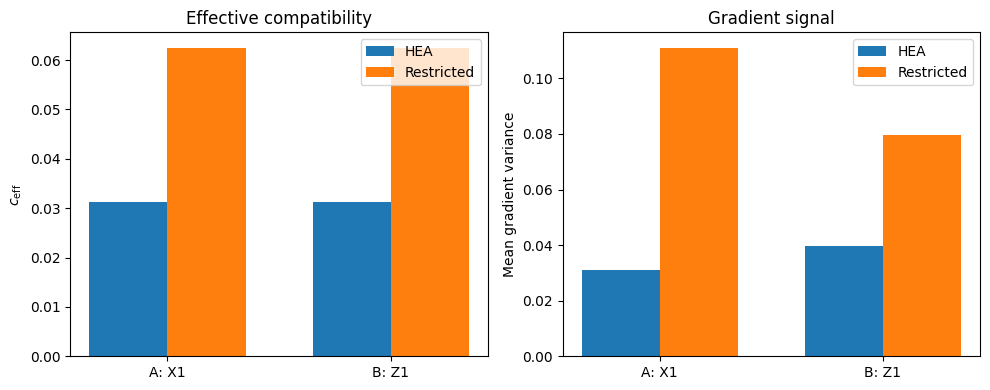

Saved: fig3_section6_2_bars.png


In [13]:
# ─── Figure 3: Bar plots (effective compatibility and gradient signal) ─────────
benchmarks = ["A: X1", "B: Z1"]
hea_c = [float(out_hea_x1["c_eff"][0]), float(out_hea_z1["c_eff"][0])]
res_c = [float(out_res_x1["c_eff"][0]), float(out_res_z1["c_eff"][0])]
hea_v = [float(out_hea_x1["grad_var_mean"][0]), float(out_hea_z1["grad_var_mean"][0])]
res_v = [float(out_res_x1["grad_var_mean"][0]), float(out_res_z1["grad_var_mean"][0])]

x, width = np.arange(len(benchmarks)), 0.35
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(x - width/2, hea_c, width, label="HEA")
axes[0].bar(x + width/2, res_c, width, label="Restricted")
axes[0].set_xticks(x);  axes[0].set_xticklabels(benchmarks)
axes[0].set_ylabel(r"$c_{\mathrm{eff}}$");  axes[0].set_title("Effective compatibility")
axes[0].legend()

axes[1].bar(x - width/2, hea_v, width, label="HEA")
axes[1].bar(x + width/2, res_v, width, label="Restricted")
axes[1].set_xticks(x);  axes[1].set_xticklabels(benchmarks)
axes[1].set_ylabel("Mean gradient variance");  axes[1].set_title("Gradient signal")
axes[1].legend()

plt.tight_layout()
plt.savefig("fig3_section6_2_bars.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved: fig3_section6_2_bars.png")

---
## 8. Section 6.3 – System-size scaling and signal dilution

We sweep $n \in \{4, 6, 8, 10\}$ qubits while keeping the ansatz structure fixed.

- The **restricted ansatz** always acts on qubits $\{0, 1\}$.
- The **HEA** grows with the system size.

**Prediction (Theorem 4.4 + Corollary 4.5):**  
HEA compatibility $c_{\mathrm{eff}}$ decays as $\sim 1/p$ (inverse number of generators),  
while the restricted ansatz preserves a stable gradient variance.

In [14]:
def run_scaling_experiment(
    qubit_list: List[int],
    reps: int = 2,
    n_samples: int = 100,
    active_qubits: List[int] = [0, 1],
    seed: int = 7,
) -> pd.DataFrame:
    """
    Run benchmarks A and B for a range of system sizes.

    The restricted ansatz always acts on `active_qubits`, regardless of n.
    Returns a DataFrame with columns:
      n_qubits, benchmark, ansatz, num_params, c_eff, grad_var_mean, grad_var_std
    """
    rows = []
    for n in qubit_list:
        print(f"\nRunning n = {n} qubits...")
        psi0_n      = zero_state(n)
        psi_plus0_n = plus_zero_state(n, plus_qubit=0)
        obs_x1_n    = observable_local_x(n, target=0)
        obs_z1_n    = observable_local_z(n, target=0)

        hea_n        = hardware_efficient_ansatz(n, reps=reps)
        restricted_n = restricted_local_ansatz(n, active_qubits=active_qubits, reps=reps)

        configs = [
            ("A: X1 with |0...0>",  hea_n,        obs_x1_n, psi0_n),
            ("A: X1 with |0...0>",  restricted_n, obs_x1_n, psi0_n),
            ("B: Z1 with |+0...0>", hea_n,        obs_z1_n, psi_plus0_n),
            ("B: Z1 with |+0...0>", restricted_n, obs_z1_n, psi_plus0_n),
        ]
        for benchmark, ans, obs, state in configs:
            out = run_benchmark(ans, obs, state, n_samples=n_samples, seed=seed)
            rows.append({
                "n_qubits":      n,
                "benchmark":     benchmark,
                "ansatz":        "HEA" if ans is hea_n else "Restricted",
                "num_params":    len(ans.parameters),
                "c_eff":         float(out["c_eff"][0]),
                "grad_var_mean": float(out["grad_var_mean"][0]),
                "grad_var_std":  float(np.std(out["grad_var_per_param"])),
            })
        print(f"  n = {n} done.")

    return pd.DataFrame(rows)

In [15]:
# ─── Run scaling experiment ────────────────────────────────────────────────────
# Note: larger system sizes (n=10) may take a few minutes with n_samples=100.
df_scaling = run_scaling_experiment(
    qubit_list=[4, 6, 8, 10],
    reps=2,
    n_samples=100,
    active_qubits=[0, 1],
    seed=SEED,
)

print("\n=== SCALING SUMMARY TABLE (Section 6.3) ===")
print(df_scaling.to_string(index=False))
df_scaling.to_csv("section6_3_scaling_summary.csv", index=False)
print("\nSaved: section6_3_scaling_summary.csv")


Running n = 4 qubits...
  n = 4 done.

Running n = 6 qubits...
  n = 6 done.

Running n = 8 qubits...
  n = 8 done.

Running n = 10 qubits...
  n = 10 done.

=== SCALING SUMMARY TABLE (Section 6.3) ===
 n_qubits           benchmark     ansatz  num_params    c_eff  grad_var_mean  grad_var_std
        4  A: X1 with |0...0>        HEA          16 0.031250       0.028918      0.026521
        4  A: X1 with |0...0> Restricted           8 0.062500       0.111124      0.048008
        4 B: Z1 with |+0...0>        HEA          16 0.031250       0.037663      0.086356
        4 B: Z1 with |+0...0> Restricted           8 0.062500       0.082966      0.112505
        6  A: X1 with |0...0>        HEA          24 0.005208       0.019023      0.026453
        6  A: X1 with |0...0> Restricted           8 0.015625       0.111124      0.048008
        6 B: Z1 with |+0...0>        HEA          24 0.005208       0.026620      0.073148
        6 B: Z1 with |+0...0> Restricted           8 0.015625       0

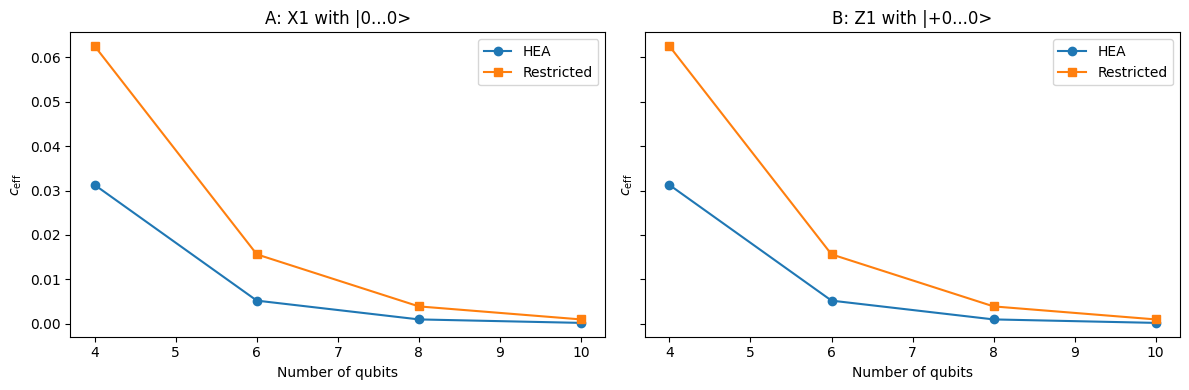

Saved: fig4_section6_3_ceff_scaling.png


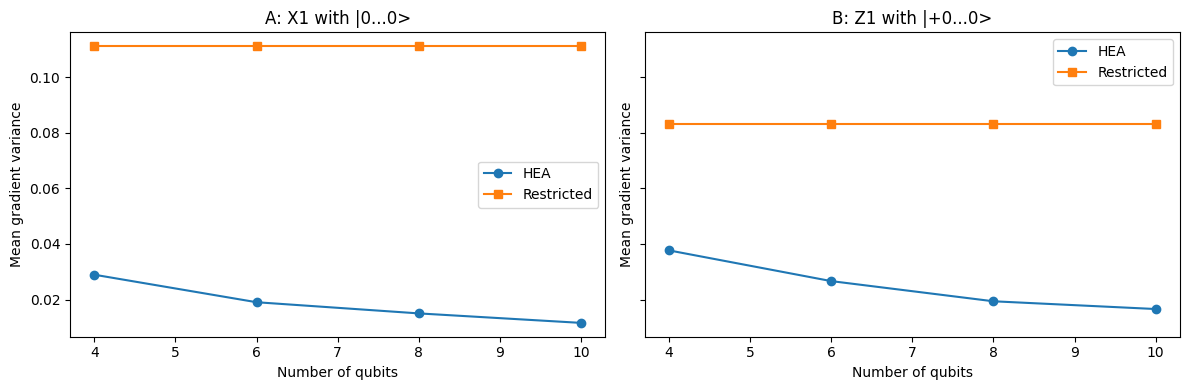

Saved: fig5_section6_3_gradvar_scaling.png


In [16]:
# ─── Figure 4 & 5: Scaling plots ──────────────────────────────────────────────
def plot_scaling(df: pd.DataFrame, y_col: str, y_label: str, filename: str) -> None:
    benchmarks = df["benchmark"].unique()
    fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

    for ax, bm in zip(axes, benchmarks):
        df_b   = df[df["benchmark"] == bm]
        df_hea = df_b[df_b["ansatz"] == "HEA"].sort_values("n_qubits")
        df_res = df_b[df_b["ansatz"] == "Restricted"].sort_values("n_qubits")

        ax.plot(df_hea["n_qubits"], df_hea[y_col], marker="o", label="HEA")
        ax.plot(df_res["n_qubits"], df_res[y_col], marker="s", label="Restricted")
        ax.set_title(bm);  ax.set_xlabel("Number of qubits")
        ax.set_ylabel(y_label);  ax.legend()

    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Saved: {filename}")


plot_scaling(df_scaling, "c_eff",         r"$c_{\mathrm{eff}}$",
             "fig4_section6_3_ceff_scaling.png")
plot_scaling(df_scaling, "grad_var_mean",  "Mean gradient variance",
             "fig5_section6_3_gradvar_scaling.png")

---
## 9. Section 6.4 – Algebra–observable alignment

We compare two restricted ansätze that differ **only in their qubit support**:

- **Aligned** $\{0, 1\}$: overlaps with the support of the observable (qubit 0).
- **Misaligned** $\{2, 3\}$: completely disjoint from the observable support.

**Prediction (Theorem 4.6 + Proposition 4.7):**  
When the algebra is disjoint from the observable, $[O, \rho]$ has zero projection  
onto the accessible algebra, so $c_{\mathrm{eff}} = 0$ and gradient variance $= 0$.

In [17]:
def run_alignment_experiment(
    num_qubits: int = 4,
    reps: int = 2,
    n_samples: int = 200,
    seed: int = 7,
) -> pd.DataFrame:
    """
    Compare aligned {0,1} vs. misaligned {2,3} restricted ansätze.
    Observable always acts on qubit 0.

    Returns a summary DataFrame.
    """
    psi0_n       = zero_state(num_qubits)
    psi_plus0_n  = plus_zero_state(num_qubits, plus_qubit=0)
    obs_x1_n     = observable_local_x(num_qubits, target=0)
    obs_z1_n     = observable_local_z(num_qubits, target=0)

    aligned    = restricted_local_ansatz(num_qubits, active_qubits=[0, 1], reps=reps)
    misaligned = restricted_local_ansatz(num_qubits, active_qubits=[2, 3], reps=reps)

    rows = []
    configs = [
        ("A: X1 with |0...0>",  aligned,    obs_x1_n, psi0_n,      "Aligned ({0,1})"),
        ("A: X1 with |0...0>",  misaligned, obs_x1_n, psi0_n,      "Misaligned ({2,3})"),
        ("B: Z1 with |+0...0>", aligned,    obs_z1_n, psi_plus0_n, "Aligned ({0,1})"),
        ("B: Z1 with |+0...0>", misaligned, obs_z1_n, psi_plus0_n, "Misaligned ({2,3})"),
    ]
    for benchmark, ans, obs, state, config_label in configs:
        out = run_benchmark(ans, obs, state, n_samples=n_samples, seed=seed)
        rows.append({
            "benchmark":     benchmark,
            "configuration": config_label,
            "c_eff":         float(out["c_eff"][0]),
            "grad_var_mean": float(out["grad_var_mean"][0]),
            "grad_var_std":  float(np.std(out["grad_var_per_param"])),
            "grad_var_min":  float(np.min(out["grad_var_per_param"])),
            "grad_var_max":  float(np.max(out["grad_var_per_param"])),
        })

    df = pd.DataFrame(rows)
    print("\n=== ALIGNMENT SUMMARY TABLE (Section 6.4) ===")
    print(df.to_string(index=False))
    df.to_csv("section6_4_alignment_summary.csv", index=False)
    print("\nSaved: section6_4_alignment_summary.csv")
    return df

In [18]:
df_alignment = run_alignment_experiment(num_qubits=4, reps=REPS, n_samples=N_SAMPLES, seed=SEED)

# Optional: display circuit diagrams for both configurations
# aligned_spec    = restricted_local_ansatz(4, active_qubits=[0, 1], reps=REPS)
# misaligned_spec = restricted_local_ansatz(4, active_qubits=[2, 3], reps=REPS)
# print_circuit_info(aligned_spec)
# print_circuit_info(misaligned_spec)


=== ALIGNMENT SUMMARY TABLE (Section 6.4) ===
          benchmark      configuration  c_eff  grad_var_mean  grad_var_std  grad_var_min  grad_var_max
 A: X1 with |0...0>    Aligned ({0,1}) 0.0625       0.111037      0.040141  5.303713e-02      0.180321
 A: X1 with |0...0> Misaligned ({2,3}) 0.0000       0.000000      0.000000  0.000000e+00      0.000000
B: Z1 with |+0...0>    Aligned ({0,1}) 0.0625       0.079696      0.112963  3.579456e-33      0.292715
B: Z1 with |+0...0> Misaligned ({2,3}) 0.0000       0.000000      0.000000  0.000000e+00      0.000000

Saved: section6_4_alignment_summary.csv


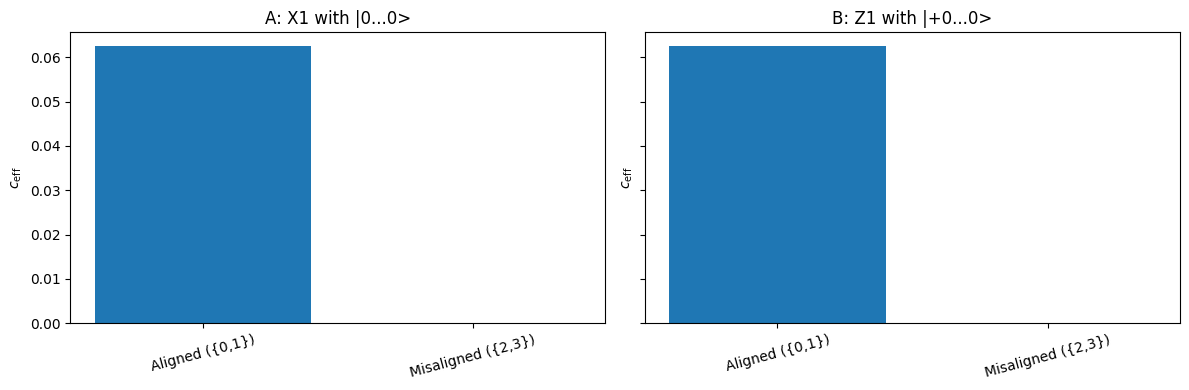

Saved: fig6_section6_4_alignment_ceff.png


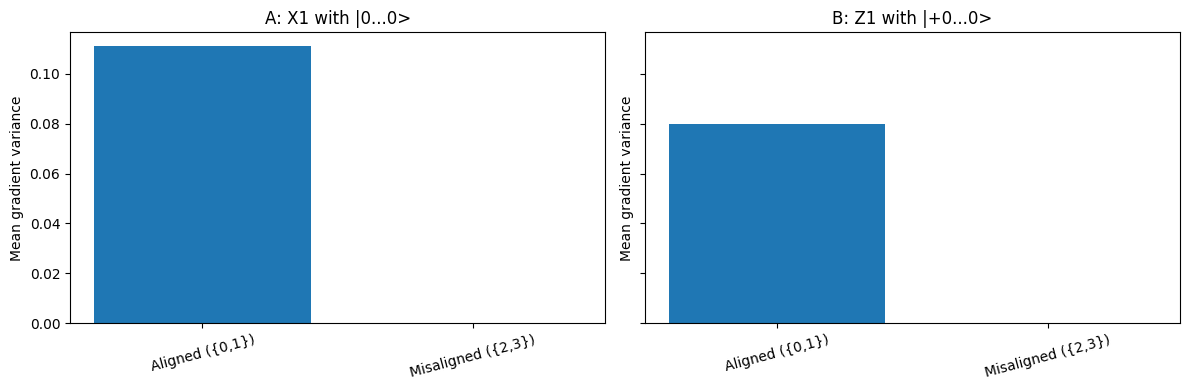

Saved: fig7_section6_4_alignment_gradvar.png


In [19]:
# ─── Figure 6 & 7: Alignment bar plots ────────────────────────────────────────
def plot_alignment(df: pd.DataFrame, y_col: str, y_label: str, filename: str) -> None:
    benchmarks = df["benchmark"].unique()
    configs    = ["Aligned ({0,1})", "Misaligned ({2,3})"]
    fig, axes  = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

    for ax, bm in zip(axes, benchmarks):
        df_b   = df[df["benchmark"] == bm]
        values = [float(df_b[df_b["configuration"] == c][y_col].iloc[0]) for c in configs]
        x = np.arange(len(configs))
        ax.bar(x, values)
        ax.set_xticks(x);  ax.set_xticklabels(configs)
        ax.set_title(bm);  ax.set_ylabel(y_label)
        ax.tick_params(axis="x", rotation=15)

    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Saved: {filename}")


plot_alignment(df_alignment, "c_eff",         r"$c_{\mathrm{eff}}$",
               "fig6_section6_4_alignment_ceff.png")
plot_alignment(df_alignment, "grad_var_mean",  "Mean gradient variance",
               "fig7_section6_4_alignment_gradvar.png")